In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## Data Merge

#### Load data

In [2]:
# path to all csv files
paths = []
for root, dirs, files in os.walk("D:/Julie/develop/桃儲/fpccoil_data_220721"):
    for f in files:
        paths.append(os.path.join(root, f))

In [3]:
# 各別合併P2, P3, P4資料夾中的csv
df2, df3, df4 = pd.DataFrame(), pd.DataFrame(), pd.DataFrame()
for path in paths:
    df = pd.read_csv(path)

    if "P2" in path:
        df2 = pd.concat([df2, df], ignore_index = True)
    elif "P3" in path:
        df.columns = ['桃儲批號', '麥寮批號', '麥寮', '桃儲', '停泵日期', '取樣時間', '檢驗完成時間', '靜置H', '導電度', '溫度℃', '密度ｋｇ／ｍ３']#有些檔案的'密度ｋｇ／ｍ３'加了"\n"，需統一
        df3        = pd.concat([df3, df], ignore_index = True)
    elif "P4" in path:
        df4 = pd.concat([df4, df], ignore_index = True)
print(len(df2), len(df3), len(df4))

373 488 296


#### Outlier

In [4]:
error_index = df2.query("end_vol <= start_vol").index
df2[["start_vol", "end_vol"]].iloc[error_index]

,start_vol,end_vol
89,6570.538,6565.229
107,6607.698,6607.698
108,6607.698,6607.698
236,5135.074,1456.167
330,6646.855,6646.323
345,1978.994,1978.994
347,6637.427,6635.834


In [5]:
df2.head(3)

,輸油批號編號,麥寮廠油槽槽號,桃儲站油槽槽號,起泵時間,停泵時間,油量增加比例,start_vol,end_vol,壓力Kg/cm2,管線溫度℃,即時流速(KL/HR),EC_0,EC_1,EC_2,EC_3,EC_4,EC_5,EC_6,EC_7
0,20201102-02-JFI-ML-TU,T-8513,T-A403,2020-11-02 21:19:00,2020-11-03 17:38:00,3.820285,1742.663,6657.470,2.460500,27.572727,223.029545,368.0,363.0,360.0,NaN,NaN,NaN,NaN,NaN
1,20201104-02-JFI-ML-TU,T-8513,T-A404,2020-11-04 20:56:00,2020-11-05 16:05:00,3.116438,1860.085,5796.840,2.664364,27.488636,220.152273,360.0,374.0,374.0,389.0,355.0,330.0,NaN,NaN
2,20201106-01-JFI-ML-TU,T-8513,T-A401,2020-11-06 02:18:00,2020-11-06 22:19:00,2.255220,1601.625,3612.017,3.877000,26.432143,180.342857,345.0,349.0,360.0,341.0,350.0,345.0,350.0,NaN


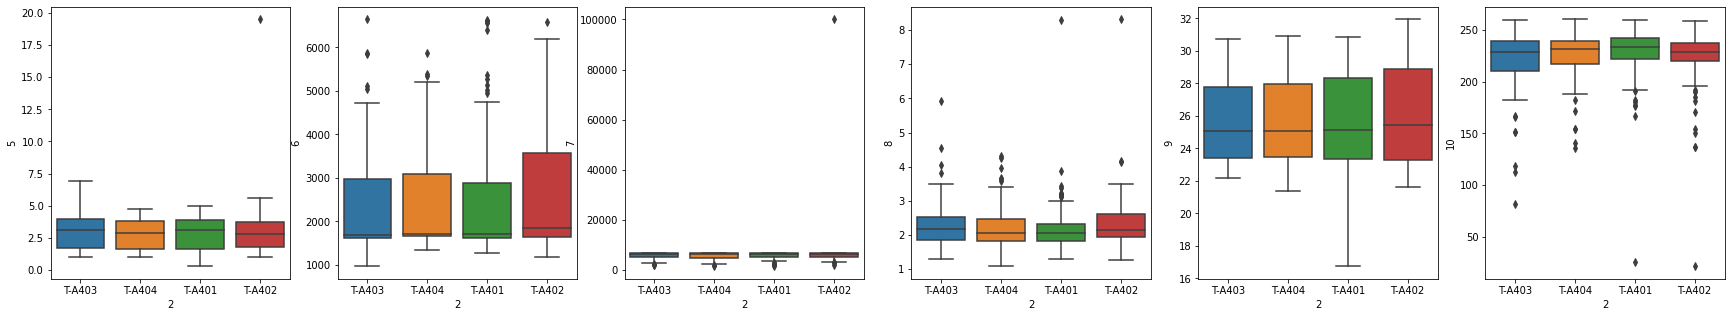

In [6]:
col = df2.columns
df2.columns = list(range(df2.shape[1]))
fig, ax = plt.subplots(1, 6, figsize = (30, 5))
k = 5
for i in range(6):
    sns.boxplot(x = 2, y = df2.columns[k], data = df2, ax = ax[i])
    k += 1
df2.columns = col

In [7]:
# 油量最多只到7000，key錯
df2.iloc[200, 7] = 7000

In [8]:
# 刪除P2 outlier
column = ["油量增加比例", '壓力Kg/cm2', '即時流速(KL/HR)']
for c in column:
    category = df2["桃儲站油槽槽號"].unique()
    for i in category:
        g    = df2.groupby("桃儲站油槽槽號")
        df   = g.get_group(i).copy()
        Q1   = df[c].quantile(0.25)
        Q3   = df[c].quantile(0.75)
        IQR  = Q3 - Q1
        min_ = Q1 - (1.5 * IQR)
        max_ = Q3 + (1.5 * IQR)
        
        df[c] = df[c].apply(lambda X: max_ if X > max_ else X)
        df[c] = df[c].apply(lambda X: min_ if X < min_ else X)
        df2.update(df)

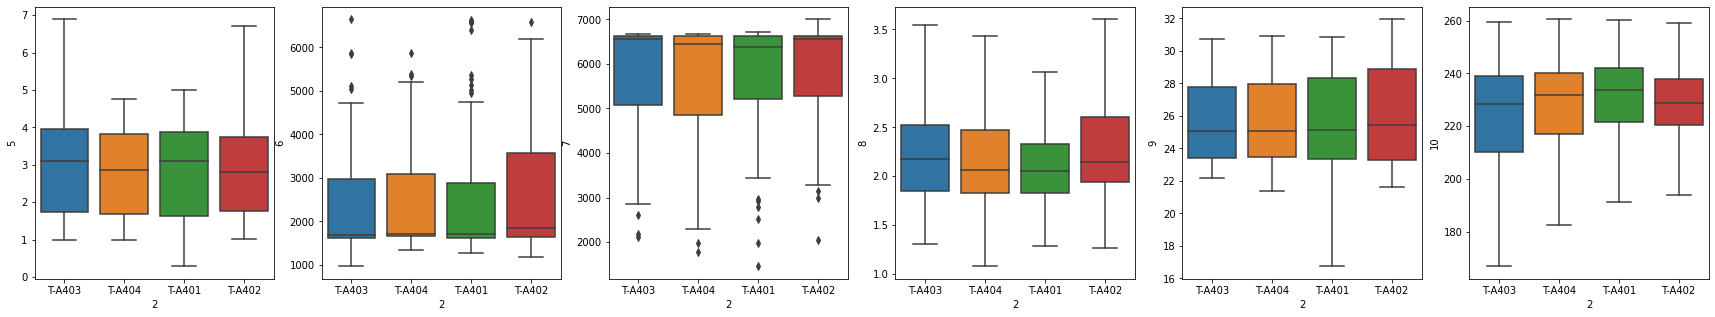

In [9]:
col = df2.columns
df2.columns = list(range(df2.shape[1]))
fig, ax = plt.subplots(1, 6, figsize = (30, 5))
k = 5
for i in range(6):
    sns.boxplot(x = 2, y = df2.columns[k], data = df2, ax = ax[i])
    k += 1
df2.columns = col

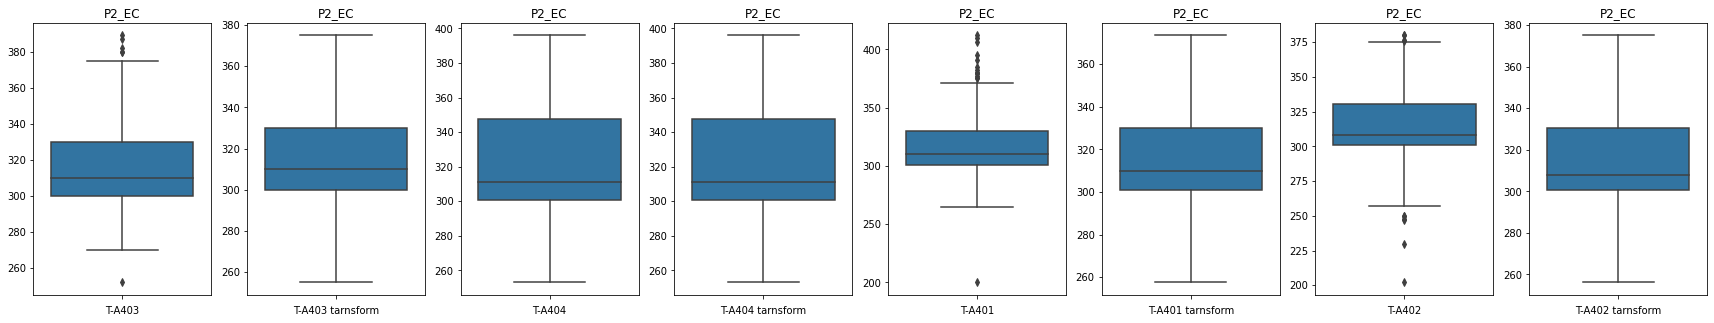

In [10]:
# 刪除P2_EC的outlier，0~7期的所有EC一起算
k   = 0
col = df2.columns[-8:]
fig, ax  = plt.subplots(1, 8, figsize = (30, 5))
category = df2["桃儲站油槽槽號"].unique()
for i in category:
    g  = df2.groupby("桃儲站油槽槽號")
    df = g.get_group(i).copy()
    EC = df[col].values.reshape(-1) #轉成一維
    EC = [j for j in EC if not np.isnan(j)] #刪除nan

    Q1   = np.quantile(EC, 0.25)
    Q3   = np.quantile(EC, 0.75)
    IQR  = Q3 - Q1
    min_ = Q1 - (1.5 * IQR)
    max_ = Q3 + (1.5 * IQR)

    df[col] = df[col].applymap(lambda X: max_ if X > max_ else X)
    df[col] = df[col].applymap(lambda X: min_ if X < min_ else X)
    df2.update(df)

    EC1 = df[col].values.reshape(-1)
    EC1 = [j for j in EC1 if not np.isnan(j)]
    
    sns.boxplot(y = EC, ax = ax[k]).set(xlabel = f"{i}", title = 'P2_EC')
    sns.boxplot(y = EC1, ax = ax[k+1]).set(xlabel = f"{i} tarnsform", title = 'P2_EC')
    k+=2

In [11]:
df3.head(3)

,桃儲批號,麥寮批號,麥寮,桃儲,停泵日期,取樣時間,檢驗完成時間,靜置H,導電度,溫度℃,密度ｋｇ／ｍ３
0,T-A401-0715,JF-512-09B2,T-8512,T-A401,2019-11-16,2019-11-18 05:00:00,2019-11-18 06:00:00,24,209,26.5,787.3
1,T-A401-0716,JF-512-09B2,T-8512,T-A401,2019-11-20,2019-11-22 05:30:00,2019-11-22 06:30:00,36,200,25.0,787.3
2,T-A401-0717,JF-514-09B3,T-8514,T-A401,2019-11-25,2019-11-26 06:00:00,2019-11-26 07:00:00,25,215,24.9,786.0


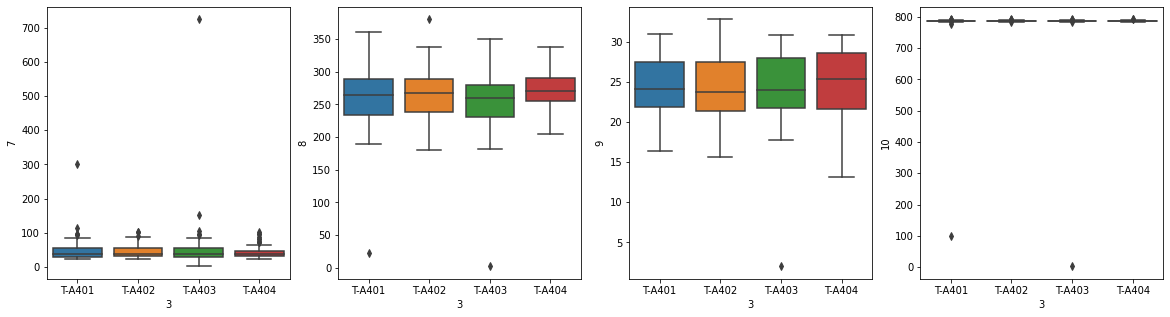

In [12]:
col = df3.columns
df3.columns = list(range(df3.shape[1]))
fig, ax = plt.subplots(1, 4, figsize = (20, 5))
k = 7
for i in range(4):
    sns.boxplot(x = 3, y = df3.columns[k], data = df3, ax = ax[i])
    k += 1
df3.columns = col

In [13]:
# 刪除P3 outlier
for c in col[7:]:
    category = df3["桃儲"].unique()
    for i in category:
        g    = df3.groupby("桃儲")
        df   = g.get_group(i).copy()
        Q1   = df[c].quantile(0.25)
        Q3   = df[c].quantile(0.75)
        IQR  = Q3 - Q1
        min_ = Q1 - (1.5 * IQR)
        max_ = Q3 + (1.5 * IQR)
        
        df[c] = df[c].apply(lambda X: max_ if X > max_ else X)
        df[c] = df[c].apply(lambda X: min_ if X < min_ else X)
        df3.update(df)

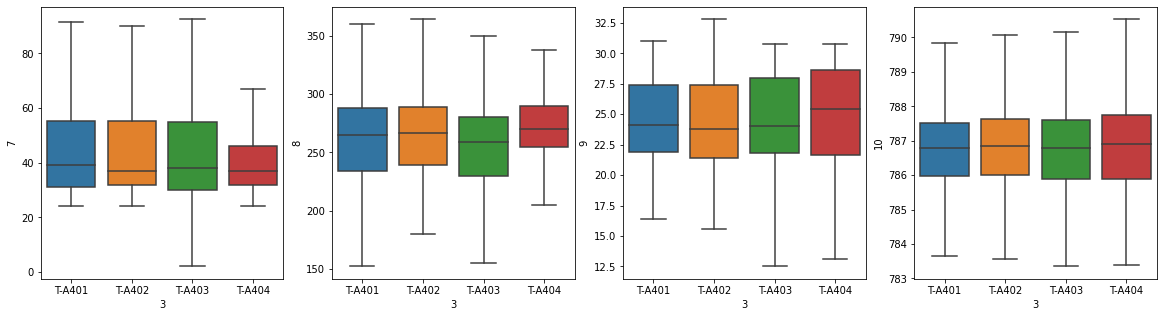

In [14]:
col = df3.columns
df3.columns = list(range(df3.shape[1]))
fig, ax = plt.subplots(1, 4, figsize = (20, 5))
k = 7
for i in range(4):
    sns.boxplot(x = 3, y = df3.columns[k], data = df3, ax = ax[i])
    k += 1
df3.columns = col

In [15]:
df4.head(3)

,輸油批號編號,桃儲站油槽槽號,桃園機場油槽槽號,起泵時間,停泵時間,start_vol,end_vol,油溫℃,管線壓力Kg/cm2,管線溫度℃,...,input_管線壓力Kg/cm2,input_管線溫度℃,EC_0,EC_1,EC_2,EC_3,EC_4,EC_5,EC_6,EC_7
0,20201102-01-JFI-TU-TUA,T-A404,T-K701,2020-11-02 17:30:03,2020/11/03 11:11,6612.219,1856.369,25.483333,9.023833,29.029167,...,3.631111,26.458333,270.0,260.0,276.0,270.0,NaN,NaN,NaN,NaN
1,20201104-01-JFI-TU-TUA,T-A401,T-K703,2020-11-04 17:04:27,2020/11/05 12:30,6626.279,3007.891,25.126316,8.881263,28.521053,...,3.616316,26.222368,287.0,286.0,290.0,290.0,290.0,NaN,NaN,NaN
2,20201105-01-JFI-TU-TUA,T-A402,T-K702,2020-11-05 16:44:00,2020/11/06 10:17,6640.853,4418.211,26.300000,8.945857,28.830357,...,3.532857,26.255357,301.0,295.0,275.0,298.0,360.0,NaN,NaN,NaN


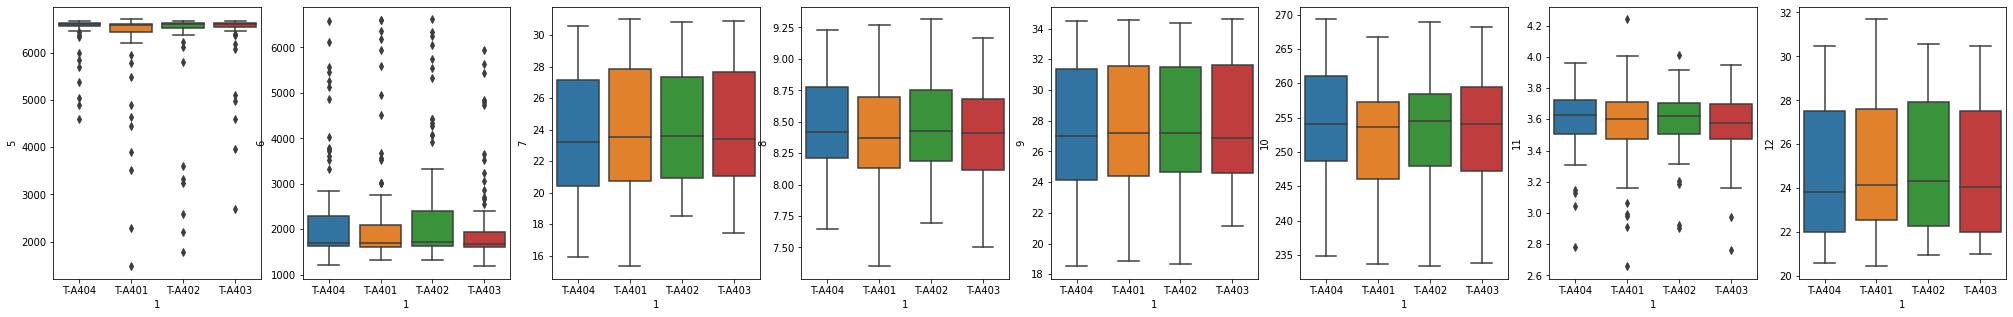

In [16]:
col = df4.columns
df4.columns = list(range(df4.shape[1]))
fig, ax = plt.subplots(1, 8, figsize = (35, 5))
k = 5
for i in range(8):
    sns.boxplot(x = 1, y = df4.columns[k], data = df4, ax = ax[i])
    k += 1
df4.columns = col

In [17]:
# 刪除P4 outlier
for c in ["input_管線壓力Kg/cm2"]:
    print(c)
    category = df4["桃儲站油槽槽號"].unique()
    for i in category:
        g    = df4.groupby("桃儲站油槽槽號")
        df   = g.get_group(i).copy()
        Q1   = df[c].quantile(0.25)
        Q3   = df[c].quantile(0.75)
        IQR  = Q3 - Q1
        min_ = Q1 - (1.5 * IQR)
        max_ = Q3 + (1.5 * IQR)
        
        df[c] = df[c].apply(lambda X: max_ if X > max_ else X)
        df[c] = df[c].apply(lambda X: min_ if X < min_ else X)
        df4.update(df)

input_管線壓力Kg/cm2


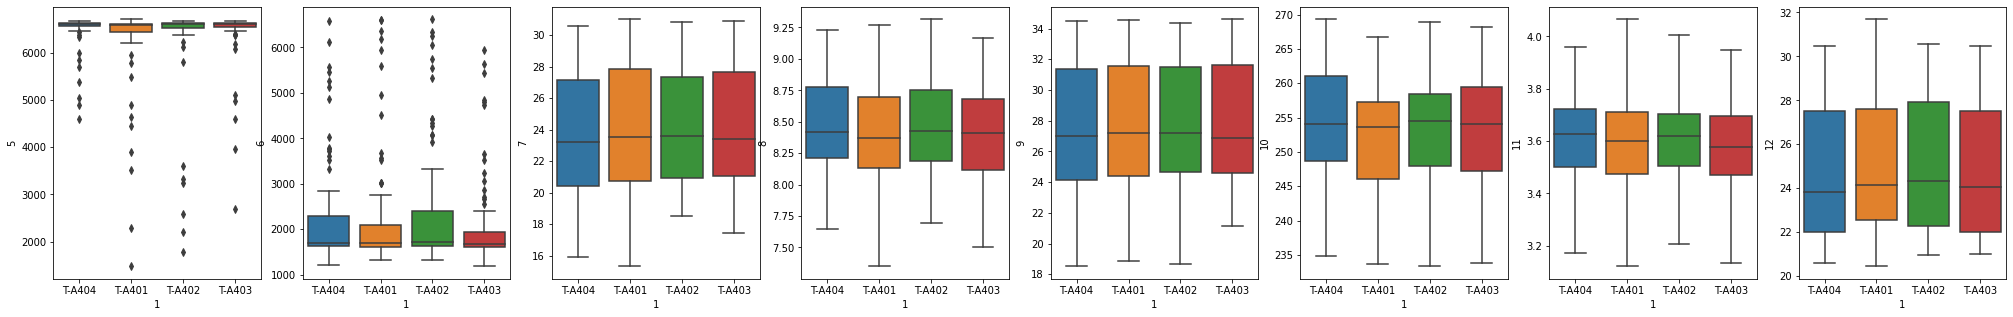

In [18]:
col = df4.columns
df4.columns = list(range(df4.shape[1]))
fig, ax = plt.subplots(1, 8, figsize = (35, 5))
k = 5
for i in range(8):
    sns.boxplot(x = 1, y = df4.columns[k], data = df4, ax = ax[i])
    k += 1
df4.columns = col

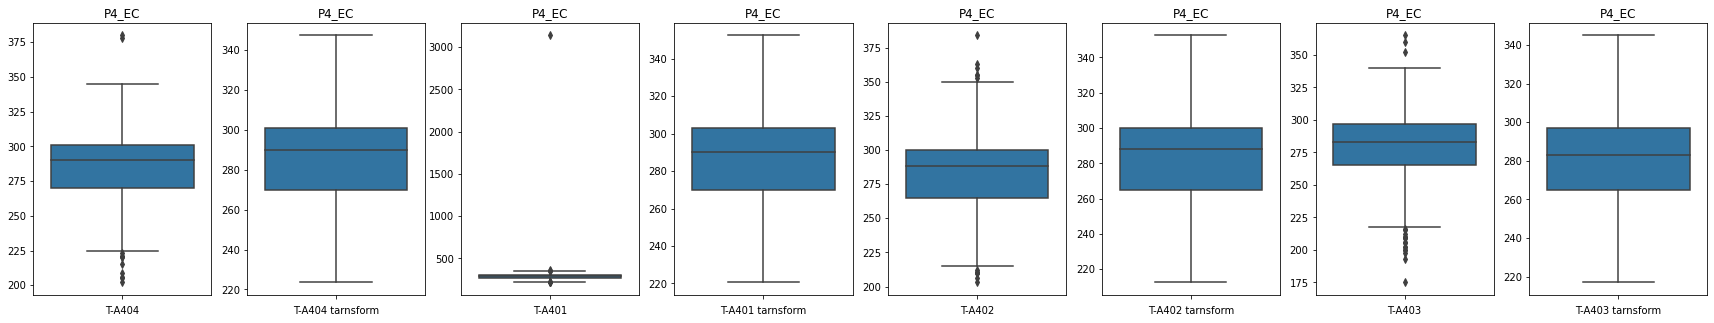

In [19]:
# 刪除P4_EC的outlier，0~7期的所有EC一起算
k   = 0
col = df4.columns[-8:]
fig, ax  = plt.subplots(1, 8, figsize = (30, 5))
category = df4["桃儲站油槽槽號"].unique()
for i in category:
    g  = df4.groupby("桃儲站油槽槽號")
    df = g.get_group(i).copy()
    EC = df[col].values.reshape(-1) #轉成一維
    EC = [j for j in EC if not np.isnan(j)] #刪除nan

    Q1   = np.quantile(EC, 0.25)
    Q3   = np.quantile(EC, 0.75)
    IQR  = Q3 - Q1
    min_ = Q1 - (1.5 * IQR)
    max_ = Q3 + (1.5 * IQR)

    df[col] = df[col].applymap(lambda X: max_ if X > max_ else X)
    df[col] = df[col].applymap(lambda X: min_ if X < min_ else X)
    df4.update(df)

    EC1 = df[col].values.reshape(-1)
    EC1 = [j for j in EC1 if not np.isnan(j)]

    sns.boxplot(y = EC, ax = ax[k]).set(xlabel = f"{i}", title = 'P4_EC')
    sns.boxplot(y = EC1, ax = ax[k+1]).set(xlabel = f"{i} tarnsform", title = 'P4_EC')
    k+=2

#### Feature generation

In [20]:
EC_end = []
for i in range(len(df4)):
    EC_end.append(df4.iloc[i, -8:].dropna()[-1])
df4["EC_end"] = EC_end

In [21]:
# 從P2(P3)輸送到P3(P4)期間，每隔一段時間會檢測油管中的EC
# 取EC_0 ~ EC_7的min、max、mean、median作為sample的EC
def EC_transform(df):
    df["EC_mean"]   = df.iloc[:, -8:].mean(axis = 1).round(1)
    df["EC_median"] = df.iloc[:, -8:].median(axis = 1).round(1)
    df["EC_max"]    = df.iloc[:, -8:].max(axis = 1).round(1)
    df["EC_min"]    = df.iloc[:, -8:].min(axis = 1).round(1)

    EC_col = ['EC_0', 'EC_1', 'EC_2', 'EC_3', 'EC_4', 'EC_5', 'EC_6', 'EC_7']
    df     = df.drop(EC_col, axis = 1)

    return df
    
df2 = EC_transform(df2)
df4 = EC_transform(df4)

#### Data Merge 

In [22]:
# mistake sample
df3.iloc[487, 4] = df3.iloc[487, 5][:10] #year
df4 = df4.drop([32]).reset_index(drop = True) #nan

In [23]:
df4.iloc[268, 4] = df4.iloc[268, 3] #time

In [24]:
# object to datetime
df2["起泵時間"]    = pd.to_datetime(df2["起泵時間"])
df2["停泵時間"]    = pd.to_datetime(df2["停泵時間"])
df3["停泵日期"]    = pd.to_datetime(df3["停泵日期"])
df3["取樣時間"]    = pd.to_datetime(df3["取樣時間"])
df3["檢驗完成時間"] = pd.to_datetime(df3["檢驗完成時間"])
df4["起泵時間"]    = pd.to_datetime(df4["起泵時間"])
df4["停泵時間"]    = pd.to_datetime(df4["停泵時間"])

In [25]:
# 先停汞才取樣，若停汞日期 > 取樣時間，資料錯誤，以取樣日期覆蓋
error_index = df3.query("停泵日期 > 取樣時間").index
df3.iloc[error_index, 4] = df3.iloc[error_index, 5].apply(lambda X: X.date())

In [26]:
# 起始時間 > 結束時間超過1天，視為錯誤sample
detect2 = (df2["起泵時間"] - df2["停泵時間"]).apply(lambda X: X.days > 1)
detect3 = (df3["取樣時間"] - df3["檢驗完成時間"]).apply(lambda X: X.days > 1)
detect4 = (df4["起泵時間"] - df4["停泵時間"]).apply(lambda X: X.days > 1)

error2_index = df2[detect2].index
error3_index = df3[detect3].index
error4_index = df4[detect4].index

df2 = df2.drop(error2_index).reset_index(drop = True)
df3 = df3.drop(error3_index).reset_index(drop = True)
df4 = df4.drop(error4_index).reset_index(drop = True)

error2_index, error3_index, error4_index

(Int64Index([], dtype='int64'),
 Int64Index([], dtype='int64'),
 Int64Index([], dtype='int64'))

In [27]:
# concat p3_last, p4_last, p2, p3, p4
df2.columns = ["p2_" + i for i in df2.columns]
df3.columns = ["p3_" + i for i in df3.columns]
df4.columns = ["p4_" + i for i in df4.columns]
col3_last   = [i+"_last" for i in df3.columns]
col4_last   = [i+"_last" for i in df4.columns]
col         = col3_last + col4_last + list(df2.columns) + list(df3.columns) + list(df4.columns)

df = pd.DataFrame(np.full([len(df2), len(col)], np.nan), columns = col)

for i in range(len(df2)):
    try: 
        p2     = df2.loc[i].to_list()
        group  = df2.loc[i, "p2_桃儲站油槽槽號"]
        start2 = df2.loc[i, "p2_起泵時間"]
        end2   = df2.loc[i, "p2_停泵時間"]

        p4_last     = df4.query("p4_桃儲站油槽槽號 == @group and p4_停泵時間 < @start2").sort_values("p4_停泵時間").iloc[-1].to_list()
        start4_last = p4_last[3] #p4_起泵時間

        p3_last = df3.query("p3_桃儲 == @group and p3_檢驗完成時間 < @start4_last").sort_values("p3_檢驗完成時間").iloc[-1].to_list()

        p3   = df3.query("p3_桃儲 == @group and p3_停泵日期 >= @end2.date()").sort_values("p3_取樣時間").iloc[0].to_list()
        end3 = p3[6] #p3_檢驗完成時間

        p4 = df4.query("p4_桃儲站油槽槽號 == @group and p4_起泵時間 > @end3").sort_values("p4_起泵時間").iloc[0].to_list()

        value      = p3_last + p4_last + p2 + p3 + p4
        df.iloc[i] = value
    except: #沒有p3_last、p4_last或p3、p4
        continue

In [28]:
# 刪除沒有p3_last、p4_last或p3、p4的sample
drop_index = df[df.isnull().all(axis = 1)].index
df         = df.drop(drop_index).reset_index(drop = True)
print(len(df))

368


In [29]:
# check date
df[[
    'p3_桃儲_last', 'p3_停泵日期_last', 'p3_取樣時間_last', 'p3_檢驗完成時間_last',
    'p4_桃儲站油槽槽號_last', 'p4_起泵時間_last', 'p4_停泵時間_last',
    'p2_桃儲站油槽槽號', 'p2_起泵時間', 'p2_停泵時間',
    'p3_桃儲', 'p3_停泵日期', 'p3_取樣時間', 'p3_檢驗完成時間',
    'p4_桃儲站油槽槽號', 'p4_起泵時間', 'p4_停泵時間'
    ]].head(3)

,p3_桃儲_last,p3_停泵日期_last,p3_取樣時間_last,p3_檢驗完成時間_last,p4_桃儲站油槽槽號_last,p4_起泵時間_last,p4_停泵時間_last,p2_桃儲站油槽槽號,p2_起泵時間,p2_停泵時間,p3_桃儲,p3_停泵日期,p3_取樣時間,p3_檢驗完成時間,p4_桃儲站油槽槽號,p4_起泵時間,p4_停泵時間
0,T-A404,2020-10-29 00:00:00,2020-10-31 04:10:00,2020-10-31 05:00:00,T-A404,2020-11-02 17:30:03,2020-11-03 11:11:00,T-A404,2020-11-04 20:56:00,2020-11-05 16:05:00,T-A404,2020-11-05 00:00:00,2020-11-08 02:40:00,2020-11-08 03:40:00,T-A404,2020-11-09 16:40:02,2020-11-10 12:33:00
1,T-A401,2020-10-31 00:00:00,2020-11-02 04:10:00,2020-11-02 05:10:00,T-A401,2020-11-04 17:04:27,2020-11-05 12:30:00,T-A401,2020-11-06 02:18:00,2020-11-06 22:19:00,T-A401,2020-11-06 00:00:00,2020-11-10 03:10:00,2020-11-10 04:10:00,T-A401,2020-11-11 17:05:00,2020-11-12 11:50:00
2,T-A402,2020-11-01 00:00:00,2020-11-05 04:30:00,2020-11-05 05:30:00,T-A402,2020-11-05 16:44:00,2020-11-06 10:17:00,T-A402,2020-11-07 21:48:00,2020-11-08 15:51:00,T-A402,2020-11-08 00:00:00,2020-11-11 02:10:00,2020-11-12 03:00:00,T-A402,2020-11-12 19:26:04,2020-11-13 13:43:00


In [30]:
# drop ID
drop_col = [
       'p3_桃儲批號_last', 'p3_麥寮批號_last', 'p3_麥寮_last',
       'p4_輸油批號編號_last', 'p4_桃儲站油槽槽號_last', 'p4_桃園機場油槽槽號_last',
       'p2_輸油批號編號', 'p2_麥寮廠油槽槽號', 'p2_桃儲站油槽槽號',
       'p3_桃儲批號', 'p3_麥寮批號', 'p3_麥寮', 'p3_桃儲',
       'p4_輸油批號編號', 'p4_桃儲站油槽槽號', 'p4_桃園機場油槽槽號'
       ]

df = df.drop(drop_col, axis = 1)
df.head(3)

,p3_桃儲_last,p3_停泵日期_last,p3_取樣時間_last,p3_檢驗完成時間_last,p3_靜置H_last,p3_導電度_last,p3_溫度℃_last,p3_密度ｋｇ／ｍ３_last,p4_起泵時間_last,p4_停泵時間_last,...,p4_管線壓力Kg/cm2,p4_管線溫度℃,p4_即時流速(KL/HR),p4_input_管線壓力Kg/cm2,p4_input_管線溫度℃,p4_EC_end,p4_EC_mean,p4_EC_median,p4_EC_max,p4_EC_min
0,T-A404,2020-10-29 00:00:00,2020-10-31 04:10:00,2020-10-31 05:00:00,38.0,285.0,26.0,789.90,2020-11-02 17:30:03,2020-11-03 11:11:00,...,8.875895,28.072368,265.884211,3.495263,26.163158,248.0,248.0,248.0,248.0,248.0
1,T-A401,2020-10-31 00:00:00,2020-11-02 04:10:00,2020-11-02 05:10:00,37.0,286.0,26.3,789.85,2020-11-04 17:04:27,2020-11-05 12:30:00,...,8.866278,28.043056,265.800000,3.475000,26.004167,250.0,266.6,250.0,266.6,250.0
2,T-A402,2020-11-01 00:00:00,2020-11-05 04:30:00,2020-11-05 05:30:00,78.0,270.0,26.3,789.90,2020-11-05 16:44:00,2020-11-06 10:17:00,...,8.862722,27.809722,266.488889,3.448333,25.866667,328.0,313.2,320.6,328.0,313.2


In [31]:
df.to_csv("data_merge.csv", index = False)

## Handle p2 data

In [32]:
df = pd.read_csv("data_merge.csv")
print(len(df))
df.head(3)

368


,p3_桃儲_last,p3_停泵日期_last,p3_取樣時間_last,p3_檢驗完成時間_last,p3_靜置H_last,p3_導電度_last,p3_溫度℃_last,p3_密度ｋｇ／ｍ３_last,p4_起泵時間_last,p4_停泵時間_last,...,p4_管線壓力Kg/cm2,p4_管線溫度℃,p4_即時流速(KL/HR),p4_input_管線壓力Kg/cm2,p4_input_管線溫度℃,p4_EC_end,p4_EC_mean,p4_EC_median,p4_EC_max,p4_EC_min
0,T-A404,2020-10-29 00:00:00,2020-10-31 04:10:00,2020-10-31 05:00:00,38.0,285.0,26.0,789.90,2020-11-02 17:30:03,2020-11-03 11:11:00,...,8.875895,28.072368,265.884211,3.495263,26.163158,248.0,248.0,248.0,248.0,248.0
1,T-A401,2020-10-31 00:00:00,2020-11-02 04:10:00,2020-11-02 05:10:00,37.0,286.0,26.3,789.85,2020-11-04 17:04:27,2020-11-05 12:30:00,...,8.866278,28.043056,265.800000,3.475000,26.004167,250.0,266.6,250.0,266.6,250.0
2,T-A402,2020-11-01 00:00:00,2020-11-05 04:30:00,2020-11-05 05:30:00,78.0,270.0,26.3,789.90,2020-11-05 16:44:00,2020-11-06 10:17:00,...,8.862722,27.809722,266.488889,3.448333,25.866667,328.0,313.2,320.6,328.0,313.2


In [33]:
# 起始量<=結束量，為錯誤sample
error_index = df.query("p2_end_vol <= p2_start_vol").index
df = df.drop(error_index).reset_index(drop = True)
print(len(df))
df.head(3)

361


,p3_桃儲_last,p3_停泵日期_last,p3_取樣時間_last,p3_檢驗完成時間_last,p3_靜置H_last,p3_導電度_last,p3_溫度℃_last,p3_密度ｋｇ／ｍ３_last,p4_起泵時間_last,p4_停泵時間_last,...,p4_管線壓力Kg/cm2,p4_管線溫度℃,p4_即時流速(KL/HR),p4_input_管線壓力Kg/cm2,p4_input_管線溫度℃,p4_EC_end,p4_EC_mean,p4_EC_median,p4_EC_max,p4_EC_min
0,T-A404,2020-10-29 00:00:00,2020-10-31 04:10:00,2020-10-31 05:00:00,38.0,285.0,26.0,789.90,2020-11-02 17:30:03,2020-11-03 11:11:00,...,8.875895,28.072368,265.884211,3.495263,26.163158,248.0,248.0,248.0,248.0,248.0
1,T-A401,2020-10-31 00:00:00,2020-11-02 04:10:00,2020-11-02 05:10:00,37.0,286.0,26.3,789.85,2020-11-04 17:04:27,2020-11-05 12:30:00,...,8.866278,28.043056,265.800000,3.475000,26.004167,250.0,266.6,250.0,266.6,250.0
2,T-A402,2020-11-01 00:00:00,2020-11-05 04:30:00,2020-11-05 05:30:00,78.0,270.0,26.3,789.90,2020-11-05 16:44:00,2020-11-06 10:17:00,...,8.862722,27.809722,266.488889,3.448333,25.866667,328.0,313.2,320.6,328.0,313.2


In [34]:
# p2可能分次輸送至p3，累積至一定量後，才從p3一次輸送至p4
# 對同一油槽且同一p3時間點下的p2做加權平均
drop_index = []
p2_col     = df.columns[24:34]
g          = df.groupby(["p3_桃儲_last", "p3_取樣時間"])
for i in g.size().index:
    df1 = g.get_group(i).iloc[:, 22:34] #同一油槽且同一p3時間點下的p2 data
    if len(df1) > 1:
        group_index = list(df1.index)

        # 同一油槽且同一p3時間點下，p2上次結束的量 > p2該次開始的量，表示中間少了一個p3的資料，此sample不可用(測量可能有誤差，範圍抓300)
        error_index  = []
        detect_error = (df1["p2_end_vol"].shift(1) - df1["p2_start_vol"]) > 300
        for j, k in zip(detect_error.index, detect_error.values):
            if k:
                error_index.append(last_index)
            last_index = j
        df1 = df1.drop(error_index)

        # 同一油槽且同一p3時間點下，p2的數據做加權平均
        diff_vol = df1["p2_end_vol"] - df1["p2_start_vol"]
        for j in p2_col[3:]:
            df1[j] = sum(df1[j] * diff_vol) / sum(diff_vol)
        
        # 重新設定油量
        df1["p2_start_vol"]   = df1["p2_start_vol"].iloc[0]
        df1["p2_end_vol"]     = df1["p2_end_vol"].iloc[-1]
        df1["p2_油量增加比例"] = (df1["p2_end_vol"] - df1["p2_start_vol"]) / df1["p2_start_vol"]

        # 以df1加權的值覆蓋df原始的值
        df.iloc[df1.index[0], 22:34] = df1.iloc[0].values

        # 儲存要刪除的index
        group_index.remove(df1.index[0])
        drop_index.extend(group_index)
        
df = df.drop(drop_index).reset_index(drop = True)
print(len(df))
df.head(3)

263


,p3_桃儲_last,p3_停泵日期_last,p3_取樣時間_last,p3_檢驗完成時間_last,p3_靜置H_last,p3_導電度_last,p3_溫度℃_last,p3_密度ｋｇ／ｍ３_last,p4_起泵時間_last,p4_停泵時間_last,...,p4_管線壓力Kg/cm2,p4_管線溫度℃,p4_即時流速(KL/HR),p4_input_管線壓力Kg/cm2,p4_input_管線溫度℃,p4_EC_end,p4_EC_mean,p4_EC_median,p4_EC_max,p4_EC_min
0,T-A404,2020-10-29 00:00:00,2020-10-31 04:10:00,2020-10-31 05:00:00,38.0,285.0,26.0,789.90,2020-11-02 17:30:03,2020-11-03 11:11:00,...,8.875895,28.072368,265.884211,3.495263,26.163158,248.0,248.0,248.0,248.0,248.0
1,T-A401,2020-10-31 00:00:00,2020-11-02 04:10:00,2020-11-02 05:10:00,37.0,286.0,26.3,789.85,2020-11-04 17:04:27,2020-11-05 12:30:00,...,8.866278,28.043056,265.800000,3.475000,26.004167,250.0,266.6,250.0,266.6,250.0
2,T-A402,2020-11-01 00:00:00,2020-11-05 04:30:00,2020-11-05 05:30:00,78.0,270.0,26.3,789.90,2020-11-05 16:44:00,2020-11-06 10:17:00,...,8.862722,27.809722,266.488889,3.448333,25.866667,328.0,313.2,320.6,328.0,313.2


In [35]:
# object to datetime
time_col = [
    'p3_停泵日期_last', 'p3_取樣時間_last', 'p3_檢驗完成時間_last',
    'p4_起泵時間_last', 'p4_停泵時間_last',
    'p2_起泵時間', 'p2_停泵時間',
    'p3_停泵日期', 'p3_取樣時間', 'p3_檢驗完成時間',
    'p4_起泵時間', 'p4_停泵時間'
    ]
    
for i in time_col:
    df[i] = pd.to_datetime(df[i])

In [36]:
#時間相差太多天，可能中間有漏掉資料，視為錯誤sample
error_index   = []
detect_error1 = (df["p2_起泵時間"] - df["p3_檢驗完成時間_last"]).apply(lambda X: X.days)
detect_error2 = (df["p4_起泵時間"] - df["p2_停泵時間"]).apply(lambda X: X.days)

error_index.extend(detect_error1[detect_error1 > 30].index)
error_index.extend(detect_error2[detect_error2 > 30].index)

df = df.drop(set(error_index)).reset_index(drop = True)
print(len(df))
df.head(3)

258


,p3_桃儲_last,p3_停泵日期_last,p3_取樣時間_last,p3_檢驗完成時間_last,p3_靜置H_last,p3_導電度_last,p3_溫度℃_last,p3_密度ｋｇ／ｍ３_last,p4_起泵時間_last,p4_停泵時間_last,...,p4_管線壓力Kg/cm2,p4_管線溫度℃,p4_即時流速(KL/HR),p4_input_管線壓力Kg/cm2,p4_input_管線溫度℃,p4_EC_end,p4_EC_mean,p4_EC_median,p4_EC_max,p4_EC_min
0,T-A404,2020-10-29,2020-10-31 04:10:00,2020-10-31 05:00:00,38.0,285.0,26.0,789.90,2020-11-02 17:30:03,2020-11-03 11:11:00,...,8.875895,28.072368,265.884211,3.495263,26.163158,248.0,248.0,248.0,248.0,248.0
1,T-A401,2020-10-31,2020-11-02 04:10:00,2020-11-02 05:10:00,37.0,286.0,26.3,789.85,2020-11-04 17:04:27,2020-11-05 12:30:00,...,8.866278,28.043056,265.800000,3.475000,26.004167,250.0,266.6,250.0,266.6,250.0
2,T-A402,2020-11-01,2020-11-05 04:30:00,2020-11-05 05:30:00,78.0,270.0,26.3,789.90,2020-11-05 16:44:00,2020-11-06 10:17:00,...,8.862722,27.809722,266.488889,3.448333,25.866667,328.0,313.2,320.6,328.0,313.2


In [37]:
df.to_csv("data_weight.csv", index = False)

## Predict

#### Load Data

In [38]:
df = pd.read_csv("data_weight.csv")
print(len(df))
df.head(3)

258


,p3_桃儲_last,p3_停泵日期_last,p3_取樣時間_last,p3_檢驗完成時間_last,p3_靜置H_last,p3_導電度_last,p3_溫度℃_last,p3_密度ｋｇ／ｍ３_last,p4_起泵時間_last,p4_停泵時間_last,...,p4_管線壓力Kg/cm2,p4_管線溫度℃,p4_即時流速(KL/HR),p4_input_管線壓力Kg/cm2,p4_input_管線溫度℃,p4_EC_end,p4_EC_mean,p4_EC_median,p4_EC_max,p4_EC_min
0,T-A404,2020-10-29,2020-10-31 04:10:00,2020-10-31 05:00:00,38.0,285.0,26.0,789.90,2020-11-02 17:30:03,2020-11-03 11:11:00,...,8.875895,28.072368,265.884211,3.495263,26.163158,248.0,248.0,248.0,248.0,248.0
1,T-A401,2020-10-31,2020-11-02 04:10:00,2020-11-02 05:10:00,37.0,286.0,26.3,789.85,2020-11-04 17:04:27,2020-11-05 12:30:00,...,8.866278,28.043056,265.800000,3.475000,26.004167,250.0,266.6,250.0,266.6,250.0
2,T-A402,2020-11-01,2020-11-05 04:30:00,2020-11-05 05:30:00,78.0,270.0,26.3,789.90,2020-11-05 16:44:00,2020-11-06 10:17:00,...,8.862722,27.809722,266.488889,3.448333,25.866667,328.0,313.2,320.6,328.0,313.2


In [39]:
df[df.isnull().any(axis = 1)]

,p3_桃儲_last,p3_停泵日期_last,p3_取樣時間_last,p3_檢驗完成時間_last,p3_靜置H_last,p3_導電度_last,p3_溫度℃_last,p3_密度ｋｇ／ｍ３_last,p4_起泵時間_last,p4_停泵時間_last,...,p4_管線壓力Kg/cm2,p4_管線溫度℃,p4_即時流速(KL/HR),p4_input_管線壓力Kg/cm2,p4_input_管線溫度℃,p4_EC_end,p4_EC_mean,p4_EC_median,p4_EC_max,p4_EC_min


#### Feature generate

In [40]:
# object to datetime
time_col = [
    'p3_停泵日期_last', 'p3_取樣時間_last', 'p3_檢驗完成時間_last',
    'p4_起泵時間_last', 'p4_停泵時間_last',
    'p2_起泵時間', 'p2_停泵時間',
    'p4_停泵時間'
    ]
    
for i in time_col:
    df[i] = pd.to_datetime(df[i])

In [41]:
#各階段經過的時間(hours)
df["p3_p4_hour"] = (
    df
    .eval("p4_停泵時間_last - p3_停泵日期_last")
    .apply(lambda X: (X.days * 24) + (X.seconds / 3600))
    )
df["p4_p2_hour"] = (
    df
    .eval("p2_停泵時間 - p4_停泵時間_last")
    .apply(lambda X: (X.days * 24) + (X.seconds / 3600))
    )
df["p3_p2_hour"] = (
    df
    .eval("p2_停泵時間 - p3_停泵日期_last")
    .apply(lambda X: (X.days * 24) + (X.seconds / 3600))
    )
df["p2_p4_hour"] = (
    df
    .eval("p4_停泵時間 - p2_停泵時間")
    .apply(lambda X: (X.days * 24) + (X.seconds / 3600))
    )
    
df = df.drop(time_col, axis = 1)

In [42]:
df = df.drop(df.columns[28:-5], axis = 1) # 實際預測時不會有p3, p4，以p3_last, p4_last, p2的資料來預測p4_EC

In [43]:
# 油槽中會有上一輪p4的剩餘油，需與該輪p2的油做加權平均
p2_vol = df.eval("p2_end_vol - p2_start_vol")
df["p2_EC_mix"] = df.eval("((p4_EC_end_last * p2_start_vol) + (p2_EC_mean * @p2_vol)) / p2_end_vol")
df = df.drop(['p4_EC_end_last', 'p4_start_vol_last', 'p4_end_vol_last','p2_start_vol', 'p2_end_vol'], axis = 1)

In [44]:
# 成長率
df["p3_p4_oil_temp"] = (df["p4_油溫℃_last"] - df["p3_溫度℃_last"]) / df["p3_溫度℃_last"]
df["p4_stress"]      = (df["p4_input_管線壓力Kg/cm2_last"] - df["p4_管線壓力Kg/cm2_last"]) / df["p4_管線壓力Kg/cm2_last"]
df["p4_oil_temp"]    = (df["p4_input_管線溫度℃_last"] - df["p4_管線溫度℃_last"]) / df["p4_管線溫度℃_last"]

#### 刪除衰退量變異大的sample

<AxesSubplot:>

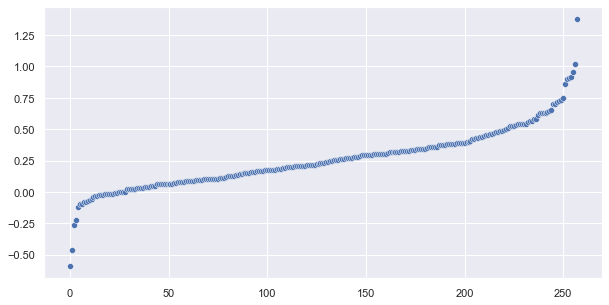

In [45]:
drop  = df.eval("(p2_EC_mix - p4_EC_min) / p2_p4_hour")
drop1 = sorted(drop)
sns.set(rc = {'figure.figsize': (10, 5)})
sns.scatterplot(x = list(range(len(drop1))), y = drop1)

In [46]:
df = df.query("(@drop < 0.80) & (@drop > -0.15)")

<AxesSubplot:>

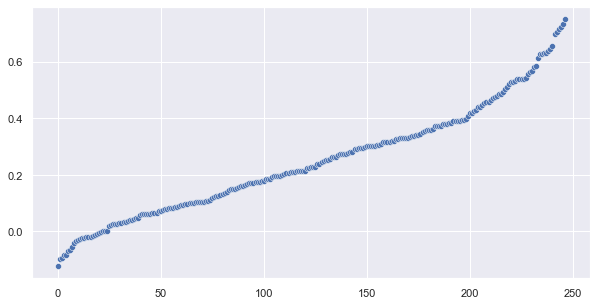

In [47]:
drop  = df.eval("(p2_EC_mix - p4_EC_min) / p2_p4_hour")
drop1 = sorted(drop)
sns.scatterplot(x = list(range(len(drop1))), y = drop1)

#### Target轉換

In [48]:
# Target改為衰退，提升預測能力
df["EC_drop"] = df.eval("p2_EC_max - p4_EC_min")
df = df.drop("p4_EC_min", axis = 1)

#### Skew

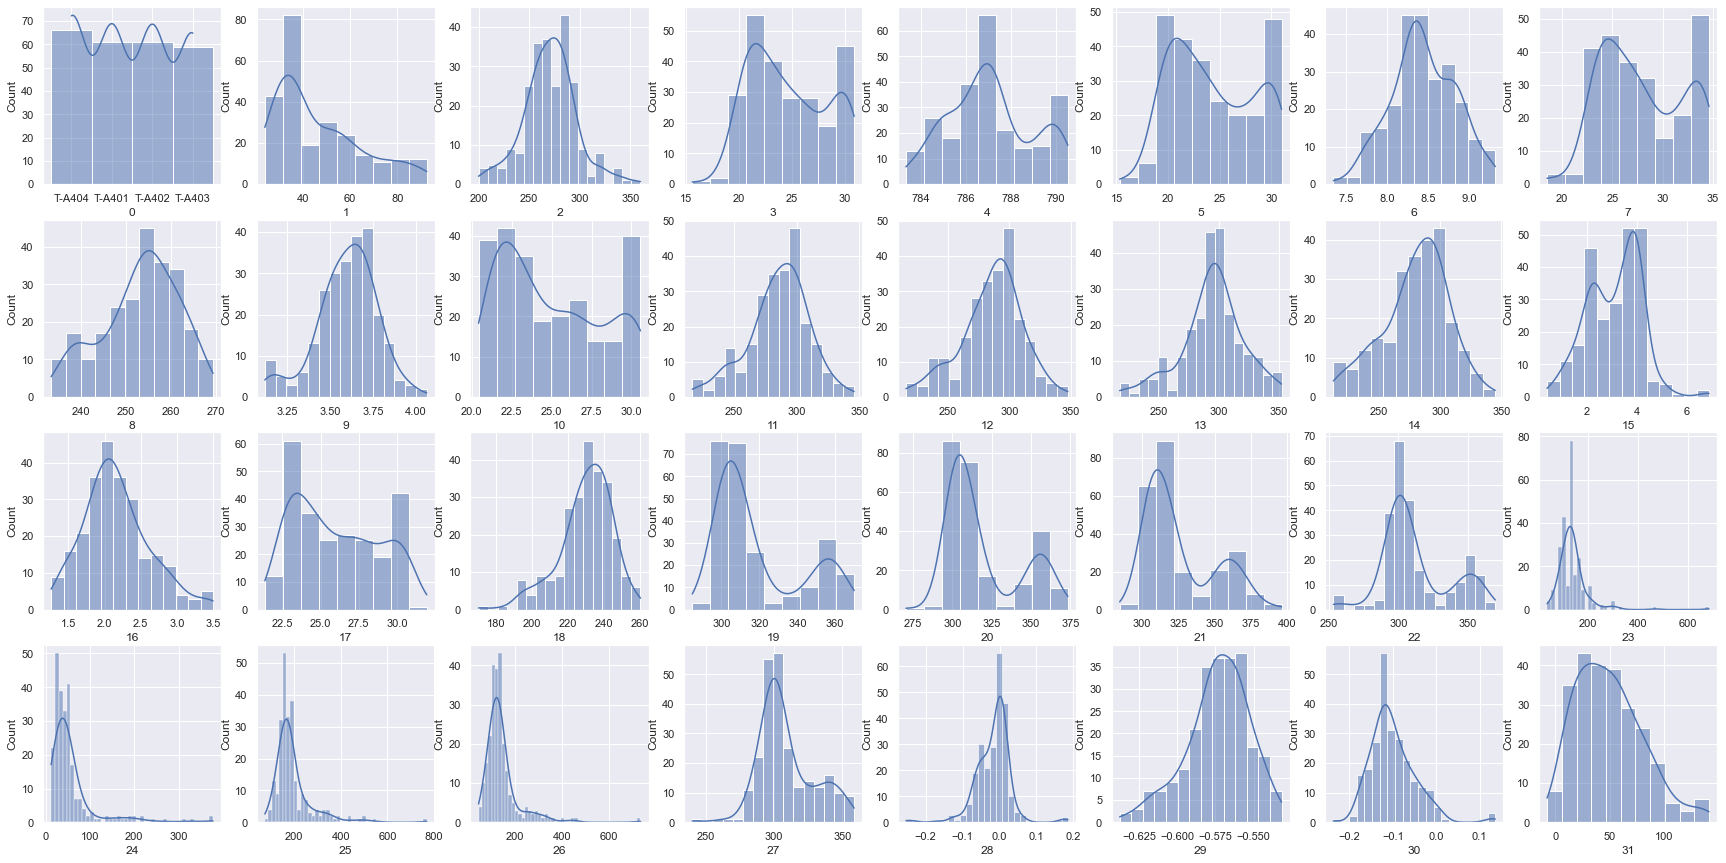

In [49]:
col = df.columns
df.columns = list(range(df.shape[1]))
fig, ax = plt.subplots(4, 8, figsize = (30, 15))
k = 0
for i in range(4):
    for j in range(8):
        sns.histplot(df[df.columns[k]], kde=True, ax = ax[i, j])
        k+=1
df.columns = col

In [50]:
from sklearn.preprocessing import PowerTransformer

skew = [1, 10, 23, 24, 25, 26]
for i in skew:
    x  = df.iloc[:, i].values.reshape(-1, 1)
    pt = PowerTransformer(method='yeo-johnson')
    df.iloc[:, i] = pt.fit_transform(x)

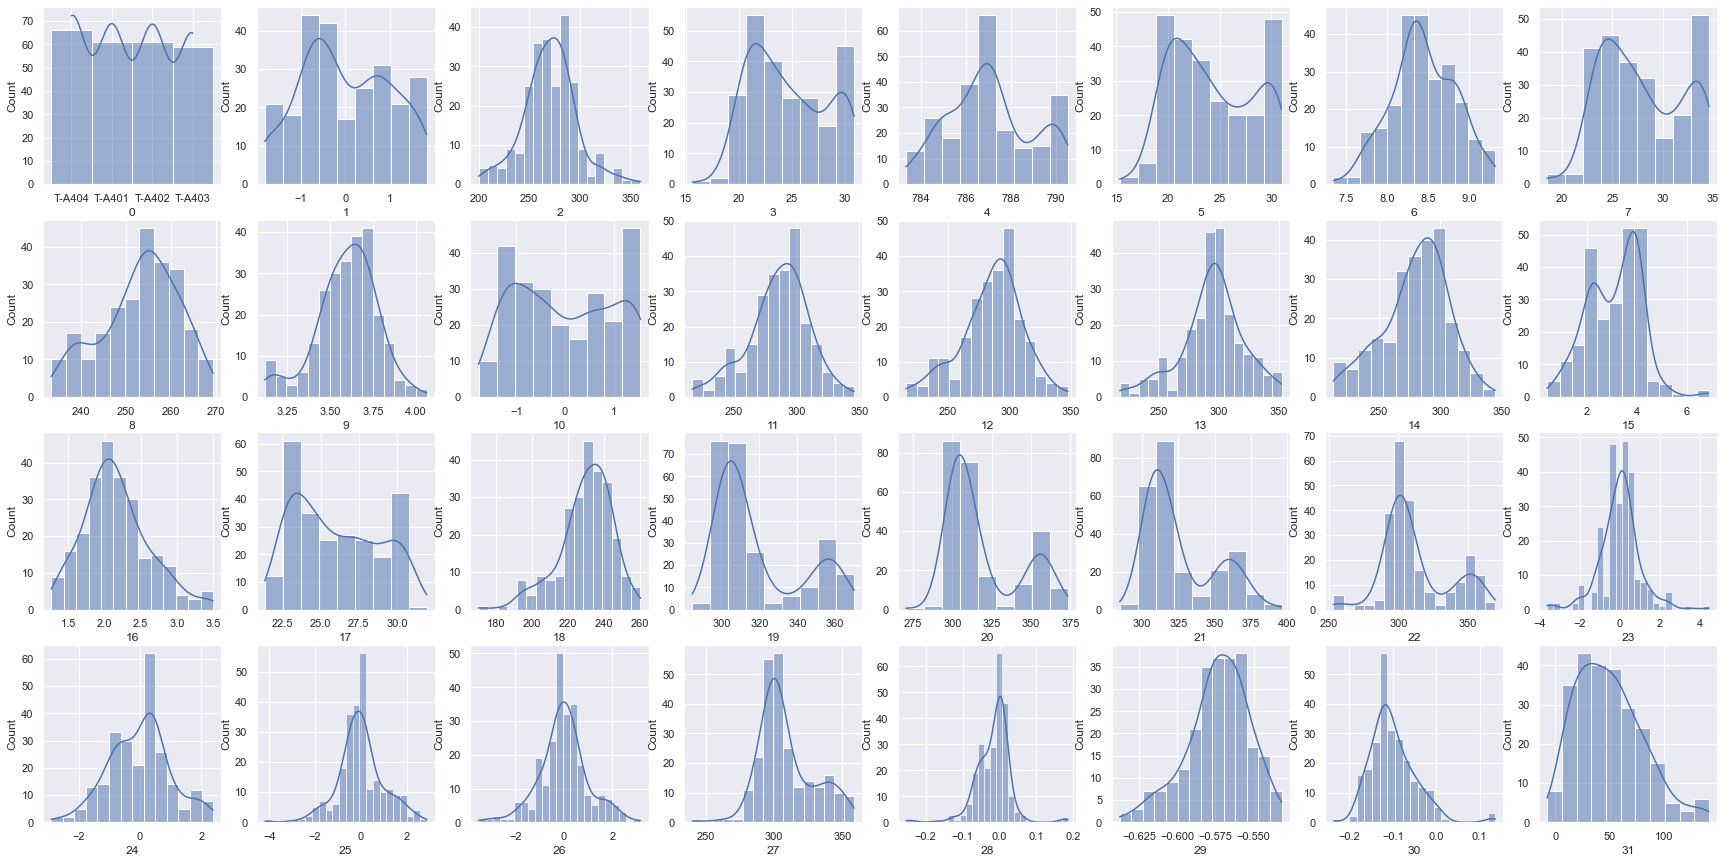

In [51]:
col = df.columns
df.columns = list(range(df.shape[1]))
fig, ax = plt.subplots(4, 8, figsize = (30, 15))
k = 0
for i in range(4):
    for j in range(8):
        sns.histplot(df[df.columns[k]], kde=True, ax = ax[i, j])
        k+=1
df.columns = col

#### Feature scaling

In [52]:
df = df.drop("p3_桃儲_last", axis = 1)

In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler() 
X_train_scaled  = scaler.fit_transform(df.iloc[:, :-1])
df.iloc[:, :-1] = X_train_scaled
df.head(3)

,p3_靜置H_last,p3_導電度_last,p3_溫度℃_last,p3_密度ｋｇ／ｍ３_last,p4_油溫℃_last,p4_管線壓力Kg/cm2_last,p4_管線溫度℃_last,p4_即時流速(KL/HR)_last,p4_input_管線壓力Kg/cm2_last,p4_input_管線溫度℃_last,...,p2_EC_min,p3_p4_hour,p4_p2_hour,p3_p2_hour,p2_p4_hour,p2_EC_mix,p3_p4_oil_temp,p4_stress,p4_oil_temp,EC_drop
0,-0.287589,0.563457,0.377326,1.549686,0.309516,1.503936,0.281154,1.600961,0.184765,0.609024,...,0.735009,0.085395,0.446134,0.169463,-0.258709,1.214002,-0.058296,-1.184490,0.228494,141.0
1,-0.366432,0.602333,0.460194,1.522459,0.219929,1.135462,0.154713,1.161434,0.100292,0.542671,...,1.188043,0.112893,-0.347490,-0.171743,0.118225,0.672540,-0.590868,-0.951240,0.381565,110.0
2,1.483780,-0.019674,0.460194,1.549686,0.514442,1.302406,0.231681,1.614324,-0.376209,0.552044,...,1.669907,0.066431,0.465854,0.165371,-0.224703,2.147979,0.369219,-1.548245,0.213979,41.8


#### Modeling

In [54]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, random_state = 777, train_size = 0.8)
train = train.reset_index(drop = True)
test  = test.reset_index(drop = True)

In [55]:
X_train = train.drop("EC_drop", axis = 1)
X_test  = test.drop("EC_drop", axis = 1)
y_train = train["EC_drop"]
y_test  = test["EC_drop"]

In [56]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import LinearSVR, SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

random_state = 99#None
models = {
    "                     Linear Regression": LinearRegression(),
    " Linear Regression (L2 Regularization)": Ridge(),
    " Linear Regression (L1 Regularization)": Lasso(),
    "                   K-Nearest Neighbors": KNeighborsRegressor(),
    "                        Neural Network": MLPRegressor(),
    "Support Vector Machine (Linear Kernel)": LinearSVR(),
    "   Support Vector Machine (RBF Kernel)": SVR(),
    "                         Decision Tree": DecisionTreeRegressor(),
    "                         Random Forest": RandomForestRegressor(random_state = random_state),
    "                     Gradient Boosting": GradientBoostingRegressor(random_state = random_state),
    "                               XGBoost": XGBRegressor(random_state = random_state),
    "                              LightGBM": LGBMRegressor(random_state = random_state),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    # print(name + " trained.")

In [57]:
from sklearn.metrics import mean_squared_error

score = []
for model in models.values():
    train_mse  = mean_squared_error(y_train, model.predict(X_train)).round(2)
    test_mse   = mean_squared_error(y_test, model.predict(X_test)).round(2)
    train_rmse =  (train_mse ** (1/2)).round(2)
    test_rmse  =  (test_mse ** (1/2)).round(2)
    train_r2   = model.score(X_train, y_train).round(2)
    test_r2    = model.score(X_test, y_test).round(2)

    score.append([train_mse, test_mse, train_rmse, test_rmse, train_r2, test_r2])

index  = [i.lstrip() for i in models.keys()]
column = ["MSE_train", "MSE_test", "RMSE_train", "RMSE_test", "R^2_train", "R^2_test"]
score  = pd.DataFrame(score, index = index, columns = column)
score

,MSE_train,MSE_test,RMSE_train,RMSE_test,R^2_train,R^2_test
Linear Regression,399.87,671.30,20.00,25.91,0.53,0.47
Linear Regression (L2 Regularization),407.40,625.36,20.18,25.01,0.53,0.51
Linear Regression (L1 Regularization),481.50,646.55,21.94,25.43,0.44,0.49
K-Nearest Neighbors,407.05,681.44,20.18,26.10,0.53,0.46
Neural Network,1108.12,1335.90,33.29,36.55,-0.29,-0.05
Support Vector Machine (Linear Kernel),544.80,842.96,23.34,29.03,0.37,0.33
Support Vector Machine (RBF Kernel),706.64,1063.61,26.58,32.61,0.18,0.16
Decision Tree,0.00,938.15,0.00,30.63,1.00,0.26
Random Forest,79.07,540.60,8.89,23.25,0.91,0.57
Gradient Boosting,30.97,440.18,5.57,20.98,0.96,0.65


In [58]:
model = models["                     Gradient Boosting"]
feature_imp = pd.DataFrame(zip(X_test.columns, model.feature_importances_), columns = ["Feature", "Value"])
feature_imp = feature_imp.sort_values(by = "Value", ascending = False)
feature_imp

,Feature,Value
20,p2_EC_max,0.313393
11,p4_EC_median_last,0.099035
7,p4_即時流速(KL/HR)_last,0.063265
5,p4_管線壓力Kg/cm2_last,0.053612
3,p3_密度ｋｇ／ｍ３_last,0.051981
0,p3_靜置H_last,0.041178
9,p4_input_管線溫度℃_last,0.030719
23,p4_p2_hour,0.028675
2,p3_溫度℃_last,0.025090
26,p2_EC_mix,0.023964


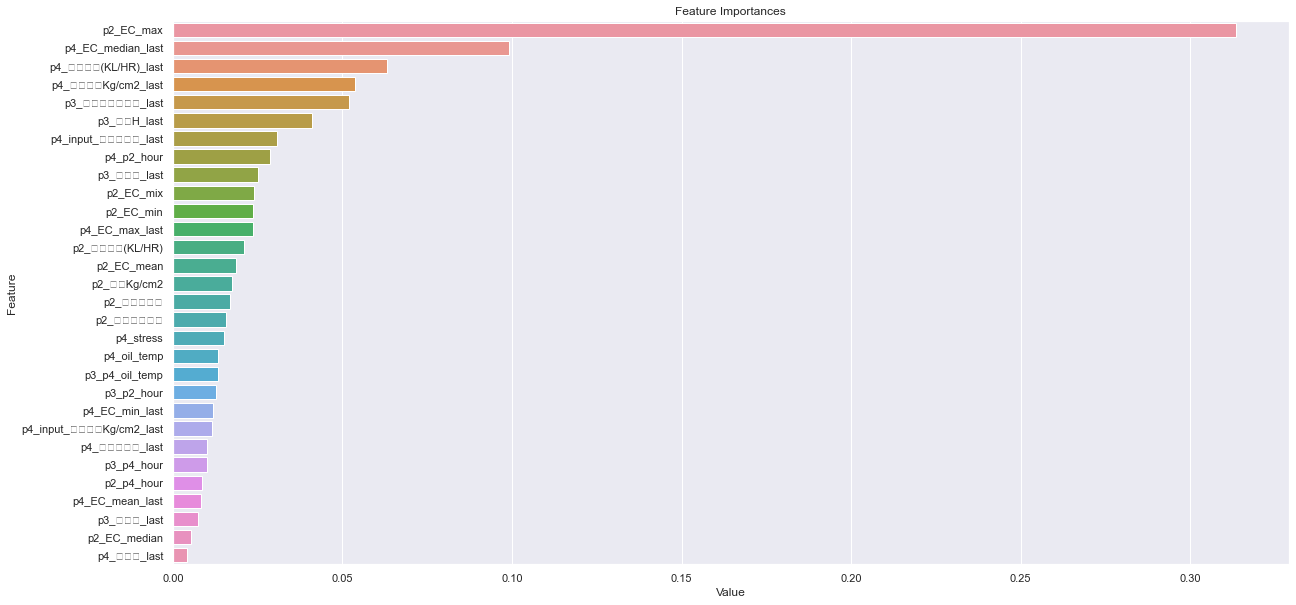

In [59]:
plt.figure(figsize=(20, 10))
sns.barplot(x = "Value", y = "Feature", data = feature_imp)
plt.title("Feature Importances")
plt.show()

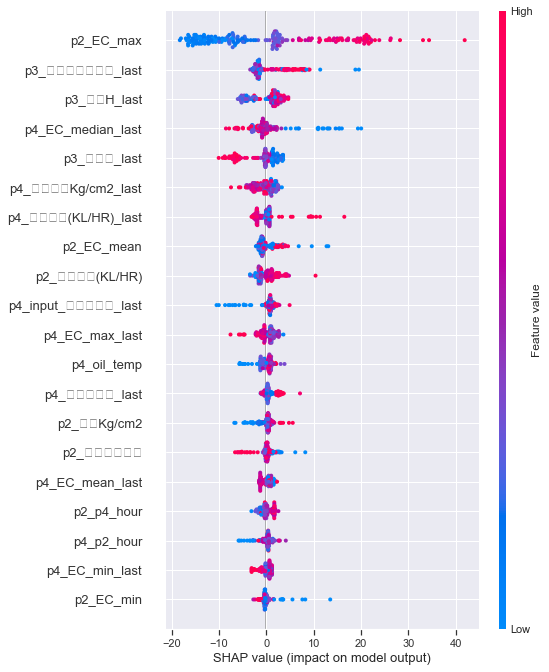

In [60]:

import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)
shap.summary_plot(shap_values, X_train)